In [ ]:
# Set up API connection
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list
# Download dataset to be used in the project
!kaggle datasets download -d purumalgi/music-genre-classification
# Unzip data and send to "data" folder
!mkdir data
!unzip music-genre-classification.zip -d data

ref                                                                    title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jayaantanaath/student-habits-vs-academic-performance                   Student Habits vs Academic Performance                   19512  2025-04-12 10:49:08.663000           7564        130  1.0              
shahriar26s/anemia-detection-dataset                                   Anemia Detection Dataset                                  2503  2025-04-26 05:34:18.807000            783         24  1.0              
adilshamim8/student-depression-dataset                                 Student Depression Dataset                              467020  2025-03-13 03:12:30.423000          2

{np.int64(5): 0, np.int64(10): 1, np.int64(6): 2, np.int64(2): 3, np.int64(4): 4, np.int64(8): 5, np.int64(9): 6, np.int64(3): 7, np.int64(7): 8, np.int64(1): 9, np.int64(0): 10}
Printing train data:
       Popularity  danceability  energy  loudness  speechiness  acousticness  \
6105         27.0         0.603   0.827    -5.222       0.0282      0.138000   
11385        56.0         0.640   0.295   -16.357       0.0397      0.425000   
5973         80.0         0.509   0.498    -6.940       0.0315      0.413000   
7715         38.0         0.681   0.849    -5.952       0.3820      0.030500   
7168         39.0         0.522   0.967    -5.218       0.1420      0.000313   

       instrumentalness  liveness  valence    tempo  time_signature  Class  
6105           0.000323    0.1230    0.664  107.009               4      9  
11385          0.000002    0.0804    0.107  121.903               4      7  
5973                NaN    0.0674    0.283   99.729               4      2  
7715       

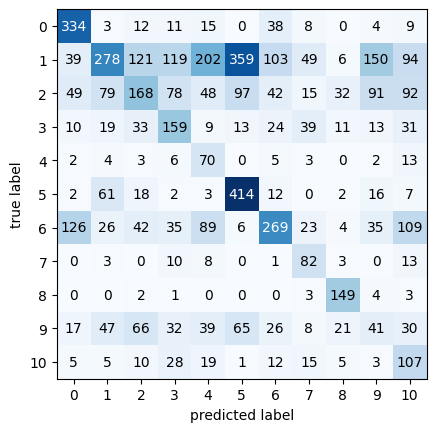

Precision: [0.57191781 0.52952381 0.35368421 0.33056133 0.13944223 0.43350785
 0.5056391  0.33469388 0.63948498 0.11420613 0.21062992]
Recall: [0.76958525 0.18289474 0.21238938 0.44044321 0.64814815 0.77094972
 0.35209424 0.68333333 0.91975309 0.10459184 0.50952381]
F1: [0.65618861 0.27188264 0.26540284 0.37767221 0.2295082  0.55495979
 0.41512346 0.44931507 0.75443038 0.10918775 0.29805014]


In [ ]:
# Since the test.csv file doesn't have labels, I'll use just the train.csv file
# and partition it into 70% train and 30% test
import pandas as pd
import xgboost as xgb
import time
# Convert csv to pandas dataframe
data = pd.read_csv('data/train.csv')

# Data preprocessing
# key and mode are being dropped as key/mode data tends to be pretty inaccurate
data.drop('key', axis=1, inplace=True)
data.drop('mode', axis=1, inplace=True)
# duration_in_min/ms is dropped since having the time formatted in two different
# ways would likely confuse the model
data.drop('duration_in min/ms', axis=1, inplace=True)
# Artist/Track Name are dropped since values are mostly unique throughout the
# dataset, meaning the model has a hard time finding a correlation since these
# are String types (you could likely incorporate some kind of word embedding,
# but that's beyond the scope of this project. Even then, names of artists tend
# to be mostly unique words)
data.drop('Track Name', axis=1, inplace=True)
data.drop('Artist Name', axis=1, inplace=True)
# This leaves the dataset with 11 features of the original 16

# This model allows the user to choose which genres to include in classification,
# whether all genres are ran together or different smaller sets of genres are examined.
# Genre mappings are:
# 0: Acoustic/Folk
# 1: Alt
# 2: Blues
# 3: Bollywood
# 4: Country
# 5: HipHop
# 6: Indie
# 7: Instrumental
# 8: Metal
# 9: Pop
# 10: Rock
# Note that some of these genres have more datapoints than others. Downsampling
# is done later in the program to accomodate for this.

# List of classes to include (edit to include different genres)
included_classes = {0,1,2,3,4,5,6,7,8,9,10}
# Remap classes
class_mappings = {}
i = 0
for class_ in data['Class'].unique():
  if class_ not in included_classes:
    class_mappings[class_] = -1
  else:
    class_mappings[class_] = i
    i += 1
print(class_mappings)
# Filter out the unwanted genres and relabel the remaining ones
data = data[data['Class'].map(class_mappings) != -1]
data['Class'] = data['Class'].map(class_mappings)

# Pick training and testing parts of this dataframe
train_data = data.sample(frac=0.7)
test_data = data.drop(train_data.index)
# Divide data into X and y
Xtr = train_data.drop('Class', axis=1)
ytr = train_data['Class']
Xte = test_data.drop('Class', axis=1)
yte = test_data['Class']

# Perform an undersample. This is necessary as the train data is quite unbalanced initially.
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler()
Xtr, ytr = undersampler.fit_resample(Xtr, ytr)
# Print out some data
print('Printing train data:')
print(train_data.head())
print('\nPrinting test data:')
print(test_data.head())
print()

# Create train and test DMatrices
dtrain = xgb.DMatrix(Xtr, ytr)
dtest = xgb.DMatrix(Xte, yte)
xgb.set_config(verbosity=0)

# The model uses 10 max depth, has a learning rate of 0.005, and runs for 4000 epochs/rounds.
# num_classes changes depending on how many classes are chosen in included_classes
param = {'max_depth' : 3, 'eta': 0.005, 'num_class': len(included_classes), 'gamma': 0.1}
num_round = 4000
# Training timing starts here
start1 = time.time()
# Training phase. Training is stopped if no improvement is seen after 50 rounds.
bst = xgb.train(param, dtrain, num_round, verbose_eval=100, evals = [(dtrain, 'train'), (dtest, 'test')], early_stopping_rounds = 50)
bst.dump_model('dump.raw.txt') # In case you want to see what the model looks like
# Training time ends here
end1 = time.time()
print('Training time: ' + str(end1 - start1))
# Testing time starts here
start2 = time.time()
# Testing phase
preds = bst.predict(dtest)
# Testing time ends here
end2 = time.time()
print('Testing time: ' + str(end2 - start2))
# Evaluation phase
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
# Accuracy
accuracy = accuracy_score(yte, preds)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
# Plot confusion matrix
confusion_matrix = confusion_matrix(yte, preds)
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plot_confusion_matrix(conf_mat=confusion_matrix)
plt.xticks(range(len(included_classes)), list(included_classes))
plt.yticks(range(len(included_classes)), list(included_classes))
plt.show()
# Precision/Recall/F1 Score
prec_rec_f1 = precision_recall_fscore_support(yte, preds)
print("Precision: " + str(prec_rec_f1[0]))
print("Recall: " + str(prec_rec_f1[1]))
print("F1: " + str(prec_rec_f1[2]))